![Facial Recognition](facialrecognition.jpg)

You are a member of an elite group of data scientists, specialising in advanced facial recognition technology, this firm is dedicated to identifying and safeguarding prominent individuals from various spheres—ranging from entertainment and sports to politics and philanthropy. The team's mission is to deploy AI-driven solutions that can accurately distinguish between images of notable personalities and the general populace, enhancing the personal security of such high-profile individuals. You're to focus on Arnold Schwarzenegger, a figure whose accomplishments span from bodybuilding champion to Hollywood icon, and from philanthropist to the Governor of California. 

### **The Data**
The `lfw_arnie_nonarnie.csv` dataset contains processed facial image data derived from the "Labeled Faces in the Wild" (LFW) dataset, focusing specifically on images of Arnold Schwarzenegger and other individuals not identified as him. This dataset has been prepared to aid in the development and evaluation of facial recognition models. There are 40 images of Arnold Schwarzenegger and 150 of other people.

| Column Name | Description |
|-------------|-------------|
| PC1, PC2, ... PCN | Principal components from PCA, capturing key image features. |
| Label | Binary indicator: `1` for Arnold Schwarzenegger, `0` for others. |

In [1]:
#Import packages
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import plotly.express as px
import plotly.subplots as sp

In [2]:
#read in & inspect the data 
df = pd.read_csv("lfw_arnie_nonarnie.csv")
display(df)
display(df.info())
#get total # null values
display(df.isna().sum().sum())

,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,Label
0,-2.061987,0.581320,-0.249115,-0.631340,-1.359899,0.751619,-0.029364,1.610456,0.341402,1.286709,...,-0.356844,-0.016488,-0.228473,0.258134,0.046834,0.135742,-0.068297,0.022038,0.090003,1
1,-0.796838,-0.667228,-0.107889,0.019755,-0.686348,0.912779,0.463412,-0.238308,-0.294023,0.215470,...,-0.037243,-0.012105,-0.351285,-0.034968,0.192314,-0.015406,-0.089117,0.023588,-0.019998,1
2,5.376779,1.142695,2.543111,-2.727212,0.272785,-0.972187,1.111221,1.645502,-2.556968,-0.648781,...,0.157441,-0.333875,-0.303720,-0.085975,0.171346,0.128577,-0.118262,0.045881,-0.190158,1
3,7.029235,1.242883,-2.628079,1.224479,-1.141370,-1.620647,0.205890,1.567561,0.736200,0.010782,...,0.051040,-0.068796,0.141841,-0.227999,0.046044,0.013643,-0.125893,0.146396,0.013320,1
4,5.484822,6.752706,-4.291114,1.740412,-1.603087,-1.075175,1.919936,-0.197615,1.030596,1.451936,...,0.034412,0.265141,0.226000,0.032064,-0.113654,0.059126,-0.216803,0.025849,0.020456,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.929206,-3.957159,2.576241,-1.540631,1.856410,-1.614303,3.188085,-1.217261,1.151327,-2.676236,...,0.013772,-0.039762,0.086136,0.063404,-0.080463,-0.013714,-0.065795,-0.010540,0.162123,0
186,-1.024236,1.449931,2.817700,0.860038,2.189413,-0.367662,-1.271834,3.028353,0.416678,0.631283,...,0.509537,-0.233772,0.130392,0.265338,0.240753,0.050460,0.196740,0.188232,-0.021774,0
187,0.315339,-4.072507,-2.833906,4.247574,0.389125,-1.023541,-3.496387,0.396100,0.019430,0.596109,...,0.022678,-0.097045,0.087939,-0.047889,0.133939,-0.107379,0.188582,-0.024228,0.005198,0
188,-3.266702,-7.227386,-1.095678,1.225573,4.074849,0.778331,-1.672117,1.135591,2.143851,0.276779,...,-0.146328,0.259239,0.085519,0.032331,-0.029974,0.191246,-0.054959,-0.076376,-0.204795,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Columns: 151 entries, 0 to Label
dtypes: float64(150), int64(1)
memory usage: 224.3 KB


None

0

# Inspect the data

The original dataset has 190 rows & 151 columns. The first 150 columns, labelled "0", "1", ..., "149", pertain to principal components from a principal component analysis (PCA). The last column assigns a binary label denoting whether the row corresponds to a picture of Arnold Schwarzenegger or not.
The dataset does not have any missing values or data inconsistencies, & so no data cleaning is necessary.

In [3]:
#inspect the values of the columns
df.describe().T.sort_values('mean', ascending=False).reset_index().rename(columns={"index":'column'})

,column,count,mean,std,min,25%,50%,75%,max
0,Label,190.0,2.105263e-01,0.408760,0.000000,0.000000,0.000000,0.000000,1.000000
1,12,190.0,3.661042e-07,0.928372,-2.603788,-0.651007,-0.111309,0.634804,2.822383
2,0,190.0,3.626611e-07,4.174661,-10.353944,-3.168281,-0.156621,2.568815,11.821953
3,29,190.0,2.633232e-07,0.560240,-1.621491,-0.330861,-0.007762,0.334913,2.270050
4,123,190.0,2.491484e-07,0.194481,-0.492017,-0.125458,-0.014035,0.130513,0.829533
...,...,...,...,...,...,...,...,...,...
146,53,190.0,-2.050337e-07,0.398652,-1.100105,-0.261108,-0.010398,0.246842,1.214481
147,35,190.0,-2.168195e-07,0.511718,-1.435260,-0.281322,0.002394,0.337031,1.461314
148,11,190.0,-2.335363e-07,0.974809,-2.965084,-0.655093,0.062048,0.556919,3.291644
149,140,190.0,-2.935979e-07,0.164493,-0.489739,-0.096798,-0.005300,0.113983,0.501433


- Excluding the "Label" column, the first column ("0") has the greatest variance in values, whereas the last column ("149") has the least variance. In other words, the ranges of the values in each column gets smaller for every additional column.
- As expected with PCA, the mean of each column is very close to zero.

# Objectives
Leverage machine learning to enhance the security of influential figures by distinguishing Arnold Schwarzenegger from others.
1) Construct machine learning pipelines for three classification models. Store these initialized models in a dictionary named `models`.
2) Determine the best performing model based on cross-validation scores. Save the model's name as `best_model_name`, its parameters as `best_model_info`, and its cross-validation score as `best_model_cv_score`.
3) Evaluate the selected model and store `accuracy`, `precision`, `recall`, and `f1` on the test set.
4) Aim to achieve a minimum accuracy of 80% for at least one of the models. Save your best accuracy score as `score`.

5) As an optional step, use Matplotlib to create a confusion matrix visualization for the predictions made by your best model.

In [4]:
#assign the feature (columns "0"-"149") & target variables ("Label")
X = df.drop('Label', axis=1)
y = df['Label']
#display(X.shape, y.shape)

#split the data into training/testing sets. use stratify=y to balance the class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [11]:
#specify 3 classification models (1)
models = {"LogisticRegression":LogisticRegression(),
          "DecisionTreeClassifier":DecisionTreeClassifier(),
          "KNeighborsClassifier":KNeighborsClassifier()}

#need to specify parameters for each model (2)
param_grid = {'LogisticRegression':{'LogisticRegression__C': [0.01, 0.1, 1, 10]},
             'DecisionTreeClassifier':{'DecisionTreeClassifier__max_depth': range(2,11,1), 
                  'DecisionTreeClassifier__min_samples_split': [2,5,10,20], 
                  'DecisionTreeClassifier__random_state': [21]},
             'KNeighborsClassifier':{'KNeighborsClassifier__n_neighbors': range(1,10)}}

#split the data into 5 folds using KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#create empty dictionaries to store results for each model
model_accs = {}
model_params = {}
model_gs = {}

#for each model:
for name, model in models.items():
    #construct a pipeline to help streamline the modeling process
    pipeline = Pipeline(steps=[("scaler", StandardScaler()), (name, model)])
    #perform GridSearch cross-validation to help find the best combination of hyperparameter values
    gs_cv = GridSearchCV(pipeline, param_grid[name], cv=kf, scoring='accuracy')
    #fit the model to the data
    gs_cv.fit(X_train, y_train)
    #obtain the desired results
    model_accs[name] = gs_cv.best_score_
    model_params[name] = gs_cv.best_params_
    model_gs[name] = gs_cv

Some notes on the hyperparameters specified in the variable "param_grid".
- Logistic Regression's **C** is a parameter that helps to avoid overfitting by implementing a complexity penalty. A high value gives more weight to the training data, & a low value gives more weight to the complexity penalty at the expense of fitting the training data.
- KNN's **n_neighbors** specifies how many closest data points to consider when making predictions.
- Decision Tree Classifier:
    - **max_depth**: Specifies the number of levels in a tree. Larger values increases the complexity, but can lead to overfitting. Smaller values makes the model simpler, but can result in underfitting.
    - **min_samples_split**: Specifies the minimum number of samples required to split an internal node. Large values can prevent overfitting, but it could prevent the model from learning effectively.
    - **random_state**: Specifies a random seed to ensure that the code is reproducible.

In [13]:
#determine the best performing technique -- KNN
df_model_accs = pd.DataFrame(list(model_accs.items())).rename(columns={0:'Model', 1:'CV Score'}).sort_values('CV Score', 
                ascending=False).reset_index(drop=True)
display("The model with the highest CV score is: {} (~{}).".format(df_model_accs.nlargest(1, 'CV Score')['Model'][0],
                                                                 round(df_model_accs.nlargest(1, 'CV Score')['CV Score'][0], 3)))
#assign the specified variables
best_model_name = df_model_accs.nlargest(1, 'CV Score')['Model'][0]
best_model_info = model_params[best_model_name]
best_model_cv_score = df_model_accs.nlargest(1, 'CV Score')['CV Score'][0]

display(best_model_name, best_model_info, best_model_cv_score)

'The model with the highest CV score is: LogisticRegression (~0.829).'

'LogisticRegression'

{'LogisticRegression__C': 1}

0.8288172043010752

The main tool that can be used to change the results of the code above is the `random_state` value in the KFold() function. Originally, random_state=21 was attempted which resulted in the KNN classifier having the best performing model; however, it only scored about 76%. This variable can be played with to determine if there are any other instances that produce a better model across the three classifiers.

In [20]:
#Use the best model to evaluate the test set, store evaluation metrics (3)

#compute predictions
y_pred = model_gs[best_model_name].predict(X_test)
#compute evaluation desired metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

display(f"Accuracy: {round(accuracy,4)}")
display(f"Precision: {round(precision,4)}")
display(f"Recall: {round(recall,4)}")
display(f"F1 Score: {round(f1,4)}")

#assign best score (4)
score = accuracy

'Accuracy: 0.8158'

'Precision: 1.0'

'Recall: 0.125'

'F1 Score: 0.2222'

Some notes on these metrics:
- **Accuracy:** how many data points the model correctly predicted.
- **Precision:** the proportion of positive predictions (image was Arnold S.) that were actually correct.
- **Recall:** the proportion of actual positive instances (image was Arnold S.) that were correctly predicted.
- **F1 score:** the harmonic mean between precision & recall.

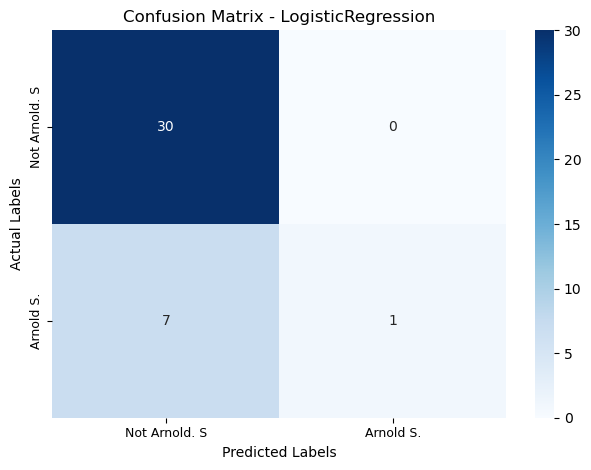

In [33]:
#Make a confusion matrix visualization (5). Can use a heatmap

#compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

#plot the data
ax1 = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Arnold. S", "Arnold S."],
                  yticklabels=["Not Arnold. S", "Arnold S."])

#edit plot details
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel('Predicted Labels')
plt.xticks(fontsize=9)
plt.ylabel('Actual Labels')
plt.yticks(fontsize=9)
plt.tight_layout();

A confusion matrix helps illustrate a machine learning model's prediction success. The values in the top left (true negatives) & bottom right (true positives) are correct predictions, whereas the values in the top right (false positives) & bottom left (false negatives) are incorrect predictions. As such, the model predicted 31/38 (~ 81.5%) of the values in the testing data correct. The details are laid in more detail below.
- Top left / true negative: Where the model predicted the image displayed someone other than Arnold Schwarzenegger when the actual data point was in fact someone other than Arnold Schwarzenegger. 30 such instances (~ 78.9%).
- Top right / false positive: Where the model predicted the image displayed Arnold Schwarzenegger when the actual data point was someone else. No such instances.
- Bottom left / false negative: Where the model predicted the image displayed someone other than Arnold Schwarzenegger when the actual data point was Arnold Schwarzenegger. Seven such instances (~ 18.4%).
- Bottom right / true positive: Where the model predicted the image displayed Arnold Schwarzenegger when the actual data point was Arnold Schwarzenegger. One such instance (~ 2.6%).